# TP Scanner
---

### DTs

Diseñar un DT para reconocer los siguientes componentes léxicos:
* **LETRAS**: cualquier secuencia de una o más letras
* **ENTERO**: cualquier secuencia de uno o más números (si tiene más de un número no deberá comenzar por 0)
* **ASIGNAR**: la secuencia =
* **SUMAR**: la secuencia +
* **RESTAR**: la secuencia -
* **IMPRIMIR**: la palabra reservada print

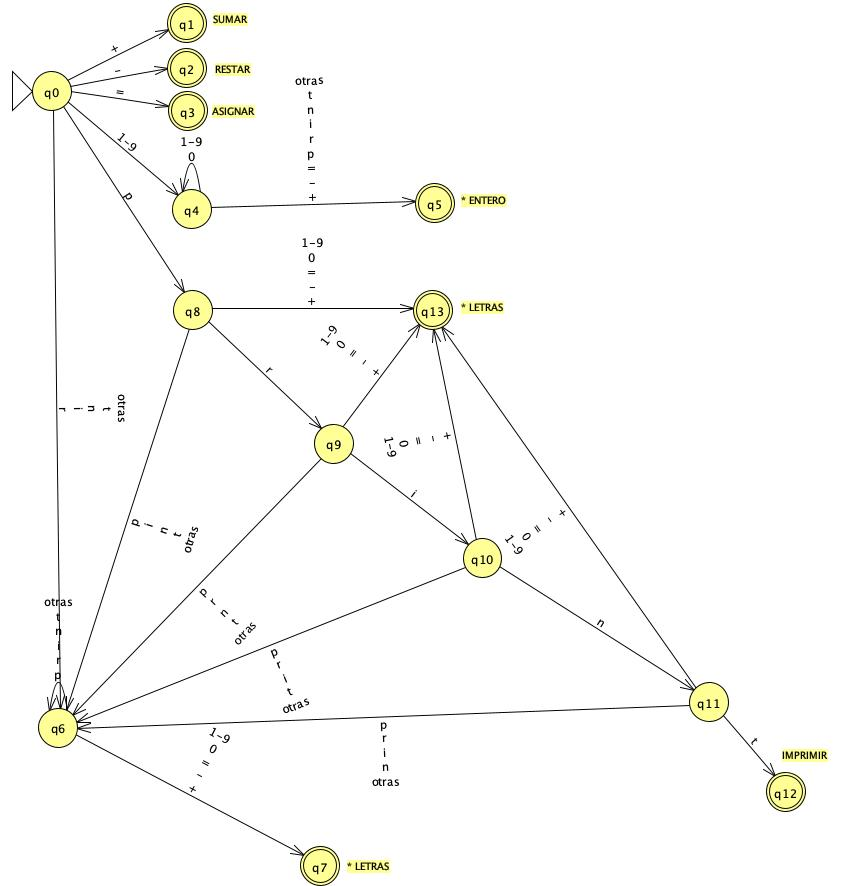

| Q  | +  | -  | =  | 0     | 1-9 | p  | r  | i  | n  | t  | Otras | Token        | Retroceso |
| -- | -- | -- | -- | --    | --  | -- | -- | -- | -- | -- | --    | --           | --        |
| 0  | 1  | 2  | 3  | error | 4   | 8  | 6  | 6  | 6  | 6  | 6     | -            | -         |
| 1  | -  | -  | -  | -     | -   | -  | -  | -  | -  | -  | -     | **SUMAR**    | 0         |
| 2  | -  | -  | -  | -     | -   | -  | -  | -  | -  | -  | -     | **RESTAR**   | 0         |
| 3  | -  | -  | -  | -     | -   | -  | -  | -  | -  | -  | -     | **ASIGNAR**  | 0         |
| 4  | 5  | 5  | 5  | 4     | 4   | 5  | 5  | 5  | 5  | 5  | 5     | -            | -         |
| 5  | -  | -  | -  | -     | -   | -  | -  | -  | -  | -  | -     | **ENTERO**   | 1         |
| 6  | 7  | 7  | 7  | 7     | 7   | 6  | 6  | 6  | 6  | 6  | 6     | -            | -         |
| 7  | -  | -  | -  | -     | -   | -  | -  | -  | -  | -  | -     | **LETRAS**   | 1         |
| 8  | 13 | 13 | 13 | 13    | 13  | 6  | 9  | 6  | 6  | 6  | 6     | -            | -         |
| 9  | 13 | 13 | 13 | 13    | 13  | 6  | 6  | 10 | 6  | 6  | 6     | -            | -         |
| 10 | 13 | 13 | 13 | 13    | 13  | 6  | 6  | 6  | 11 | 6  | 6     | -            | -         |
| 11 | 13 | 13 | 13 | 13    | 13  | 6  | 6  | 6  | 6  | 12 | 6     | -            | -         |
| 12 | -  | -  | -  | -     | -   | -  | -  | -  | -  | -  | -     | **IMPRIMIR** | 0         |
| 13 | -  | -  | -  | -     | -   | -  | -  | -  | -  | -  | -     | **LETRAS**   | 1         |

Para el lenguaje generado por la expresión regular  $(a \mid b)^* abb$
1. Crear el DT
1. Generar la tabla de transiciones
1. Escribir un programa en Python para implementar la tabla

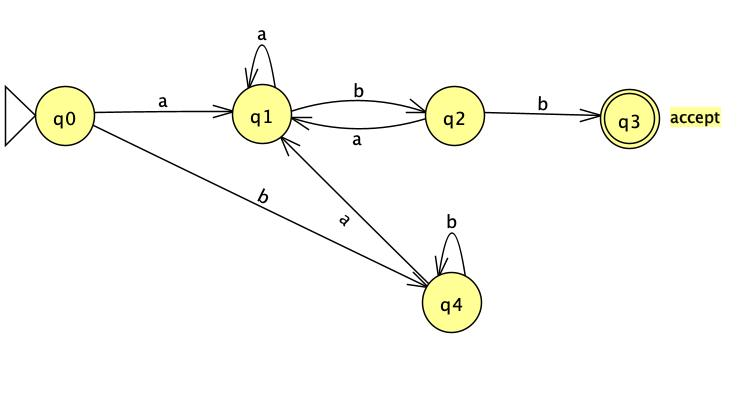

| Q  | a  | b  | Token      | Retroceso |
| -- | -- | -- | --         | --        |
| 0  | 1  | 4  | -          | -         |
| 1  | 1  | 2  | -          | -         |
| 2  | 1  | 3  | -          | -         |
| 3  | -  | -  | **accept** | 0         |
| 4  | 1  | 4  | -          | -         |

In [1]:
class Lexer: 

    ERROR = -1;
    ACEPTAR = 0;
    
    def __init__(self, palabra): 
        self.palabra = palabra
        self.cursor = -1
    
    def getCaracter(self):
        if (self.cursor + 1) < len(self.palabra):
            self.cursor += 1  
            return self.palabra[self.cursor]
        return '*'

    def q0(self):
        c = self.getCaracter()
        if c == 'a':
            return self.q1()
        if c == 'b':
            return self.q4()
        return self.ERROR
        
    def q1(self):
        c = self.getCaracter()
        if c == 'a':
            return self.q1()
        if c == 'b':
            return self.q2()
        return self.ERROR

    def q2(self):
        c = self.getCaracter()
        if c == 'a':
            return self.q1()
        if c == 'b':
            return self.q3()
        return self.ERROR

    def q3(self):
        return self.ACEPTAR;
      
    def q4(self):
        c = self.getCaracter()
        if  c == 'a':
            return self.q1()
        if c == 'b':
            return self.q4()
        return self.ERROR

In [2]:
Lexer('abb').q0()

0

In [3]:
Lexer('aabb').q0()

0

In [4]:
Lexer('babb').q0()

0

In [5]:
Lexer('ababb').q0()

0

In [6]:
Lexer('bb').q0()

-1

### Escribir un Scanner que ...

Sustituya las apariciones de un número par escrito en notación binaria por la cadena "BINARIO_PAR"

Sustituya las cadenas casa, camisa y carcasa que figuran en un texto por la cadena "CA_SA"

Reduzca a un único espacio en blanco todas las secuencias de espacios en blanco y tabuladores de un texto

Suprima los comentarios de línea de un texto (desde un # hasta el fin de la línea)

Inserte un * delante y detrás de cada carácter + que figura en un texto

Enmarque entre corchetes el carácter que precede a cada uno de los puntos que figuran en un texto

Sustituya las apariciones de un número de la semana (de 1 a 7) por su correspondiente nombre de día

Sustituya los operadores de suma +, resta -, producto * y división / y potencia ^ por la cadena "OPERADOR“

Sustituya las apariciones de un número escrito en base hexadecimal por la cadena "HEXADECIMAL"

Escriba en mayúsculas todas las palabras de un texto que comienzan por mayúsculas. (Considere que una palabra es una secuencia constituida por letras minúsculas o mayúsculas)

Sustituya todas las cadenas de un texto por el contenido de la cadena sin las comillas (Por ejemplo: "hola" sería sustituido por hola). Se define como cadena cualquier texto enmarcado entre comillas dobles con la condición de que en su contenido no figuran ni comillas dobles ni saltos de línea

Sustituya las apariciones de número reales en notación científica por la cadena "REAL". Se admiten como cadenas (lexemas): -3.4 .4 3.E10 .6e-2. No se admiten las siguientes: 45 4.6E

Sustituya las expresiones horarias que encajan o bien con el patrón HH:MM o bien con el patrón H:MM por la cadena "HORA". Tenga en cuenta que las horas deben ser correctas. Por ejemplo: 29:80 no sería una hora correcta

Sustituya las palabras de un texto que empiezan por minúsculas por la cadena MINÚSCULA y las palabras que empiecen por mayúsculas por la cadena MAYÚSCULA

Para representar fechas existen dos formatos: el americano (AAAA/DD/MM) y el europeo (DD/MM/AAAA). Escribir un scanner que imprima todas las fechas de un texto que se ajusten a uno de dichos formatos indicando además qué formato fue usado (Ignore la problemática relacionada con los años bisiestos)

Sustituya cada identificador de un texto por la cadena IDENT salvo que el identificador sea una de las palabras reservadas: If, Then o Else. En este último caso deberá imprimirse respectivamente las cadenas IF, THEN y ELSE. Las anteriores palabras reservadas no son sensibles a la capitalización, es decir, podrán aparecer mezcladas arbitrariamente letras minúsculas y mayúsculas. Por ejemplo, para la palabra reservada Else se admiten también las formas ELSe o eLsE

Distinga entre los siguientes tipos de números: entero (INT) entero largo (LONG) y real (FLOAT). Los enteros largos son enteros terminados con una letra l mayúscula o minúscula. Los reales deben incluir de forma obligatoria parte entera y parte decimal separadas por un punto

Reconozca "Identificadores de cualquier longitud que comience con a y contenga a, b o c. No pueden terminar con c y además no pueden contener dos c seguidas"

Reconozca "Identificadores sobre el alfabeto {a,b,c} que tienen por lo menos tres letras"

Reconozca "Identificadores sobre el alfabeto {%, &} cuyas palabras verificar las siguientes restricciones: 1- Si una palabra tiene menos de cinco &, entonces tiene un número par de &. 2- Si una palabra tiene cinco & o más, entonces contiene un número impar de &. 3- Cualquier palabra contiene al menos un &"

Reconozca "Una cadena comando es el nombre del comando seguido de uno o más espacios en blanco, y a continuación una lista de parámetros que puede ser vacía. Un comando es una secuencia no vacía de cadenas comando separadas por un delimitador. Un delimitador es un elemento del conjunto {. , ;}. Un nombre comienza con una letra y sigue con cero o más letras o dígitos. La lista de parámetros es una secuencia de uno o más nombres separados por uno o más espacios en blanco"